# **Preparing Dependencies**

In [1]:
# If dependencies are missing, install with uv in terminal:
# uv add torch diffusers transformers accelerate safetensors

import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

d:\Projects\VSCode Projects\idcamp-image-generation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`CLIPImageProcessor` requires torchvision (not installed); falling back to `CLIPImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `CLIPImageProcessorPil` directly to silence this warning.
`SiglipImageProcessor` requires torchvision (not installed); falling back to `SiglipImageProcessorPil` for backward compatibility. Install torchvision to use the default backend, or import `SiglipImageProcessorPil` directly to silence this warning.


# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [2]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
 )
pipe = pipe.to(DEVICE)


d:\Projects\VSCode Projects\idcamp-image-generation\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Istamosh\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 396/396 [00:00<00:00, 3664.19it/s]4.50it/s]

## **Generate Image**

100%|██████████| 50/50 [07:50<00:00,  9.42s/it]


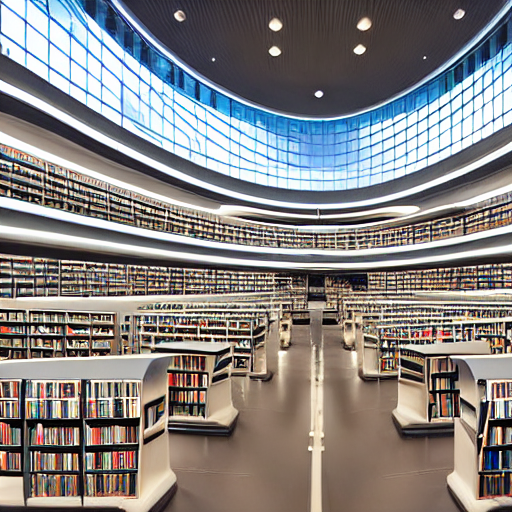

In [3]:
def generate_simple_image(prompt: str, negative_prompt: str = "", seed: int = 42):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
    )
    return result.images[0]

# Baseline example for Criterion 1
simple_prompt = "a cinematic photo of a futuristic library, highly detailed"
simple_negative_prompt = "blurry, low quality, distorted, watermark"
simple_seed = 7

image = generate_simple_image(
    prompt=simple_prompt,
    negative_prompt=simple_negative_prompt,
    seed=simple_seed,
 )
display(image)

## **Generate Image with Hyperparameter Configuration**

100%|██████████| 40/40 [06:16<00:00,  9.41s/it]


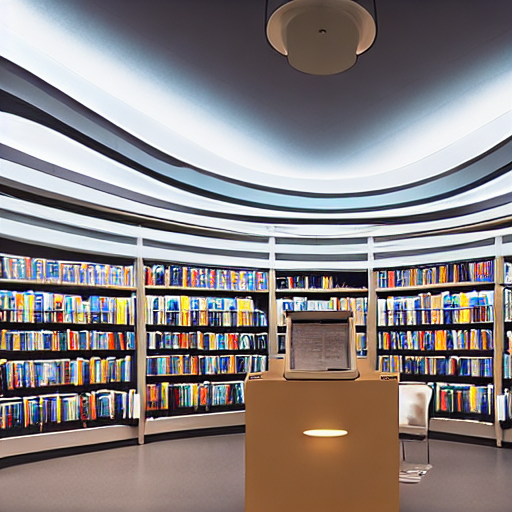

In [4]:
def generate_advanced_image(
    prompt: str,
    negative_prompt: str = "",
    seed: int = 42,
    guidance_scale: float = 7.5,
    num_inference_step: int = 50,
):
    generator_device = "cuda" if DEVICE == "cuda" else "cpu"
    generator = torch.Generator(device=generator_device).manual_seed(int(seed))

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator,
        guidance_scale=float(guidance_scale),
        num_inference_steps=int(num_inference_step),
    )
    return result.images[0]

# Example call for advanced settings
advanced_image = generate_advanced_image(
    prompt="a cinematic photo of a futuristic library, volumetric lighting",
    negative_prompt="blurry, low quality, distorted, watermark",
    seed=7,
    guidance_scale=8.5,
    num_inference_step=40,
)
display(advanced_image)

## **Guidance Scale Comparison**

### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
*"Jelaskan karakteristik gambar yang dihasilkan, seperti tingkat detail, kesesuaian dengan prompt, dan variasi visual yang terlihat."*

*   **Gambar dengan "Scale" Tinggi:**   
*"Jelaskan perbedaan yang terlihat dibandingkan guidance scale rendah, terutama pada detail gambar dan kedekatannya dengan prompt."*

## **Inference Steps Comparison**

### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
*"Jelaskan karakteristik gambar yang dihasilkan, seperti tingkat detail, ketajaman, serta kemungkinan munculnya noise atau artefak."*
*   **Gambar dengan "Step" Tinggi:**  
*"Jelaskan perbedaan yang terlihat dibandingkan step rendah, terutama pada detail gambar, kehalusan hasil, dan stabilitas visual."*

## **Batch Inference from One Prompt**

## **Load Scheduler**

### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DPM++ Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*
*   **Gambar dengan "DDIM Scheduler":**  
*"Jelaskan karakteristik gambar yang dihasilkan."*

# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Base + Refiner Image Generation**

## **Inpainting**

### **Load Model Inpainting**

### **Manual Masking**

### **Generate**

## **Inpainting Menggunakan Automasking**

### **load Model Segmentation Untuk Masking**

### **Masking with Segmentation Model**

### **Generate**

## **Outpainting**

### **Prepare the Canvas**

### **Generate**

## **Outpainting Zoom Out**

### **Prepare Canvas for Zoom Out**

### **Generate**